In [1]:

import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
GPU available: True
GPU name: Tesla T4


In [2]:
!pip install torchvision
!pip install pywavelets
!pip install matplotlib
!pip install scikit-learn

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import pywt
from sklearn.metrics import accuracy_score

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import os

data_path = "/content/drive/MyDrive/mini-imagenet"
print(os.listdir(data_path))

['test.tar', 'train.tar', 'val.tar']


In [8]:
import tarfile
import os

data_path = "/content/drive/MyDrive/mini-imagenet"
extract_path = "/content/mini-imagenet"

os.makedirs(extract_path, exist_ok=True)

for file in os.listdir(data_path):
    if file.endswith(".tar"):
        file_path = os.path.join(data_path, file)
        print(f"Extracting {file}...")
        with tarfile.open(file_path) as tar:
            tar.extractall(path=extract_path)

print("Extraction done!")

Extracting test.tar...


/tmp/ipykernel_4761/752689725.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


Extracting train.tar...
Extracting val.tar...
Extraction done!


In [10]:
print(os.listdir("/content/mini-imagenet"))

['test', 'train', 'val']


In [11]:
for split in ["train", "val", "test"]:
    split_path = f"/content/mini-imagenet/{split}"
    print(split, "number of folders:", len(os.listdir(split_path)))
    print("first 5 folders:", os.listdir(split_path)[:5])

train number of folders: 64
first 5 folders: ['n03527444', 'n13133613', 'n03476684', 'n03347037', 'n02966193']
val number of folders: 16
first 5 folders: ['n03535780', 'n02981792', 'n02114548', 'n03417042', 'n02091244']
test number of folders: 20
first 5 folders: ['n03127925', 'n02871525', 'n01930112', 'n02219486', 'n02129165']


In [12]:
sample_class = os.listdir("/content/mini-imagenet/train")[0]
sample_path = f"/content/mini-imagenet/train/{sample_class}"

print("Sample class:", sample_class)
print("Number of images:", len(os.listdir(sample_path)))
print("First 5 images:", os.listdir(sample_path)[:5])

Sample class: n03527444
Number of images: 600
First 5 images: ['n0352744400000658.jpg', 'n0352744400001114.jpg', 'n0352744400000467.jpg', 'n0352744400000648.jpg', 'n0352744400000808.jpg']


In [13]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

img_size = 224
batch_size = 32

train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.ImageFolder("/content/mini-imagenet/train", transform=train_transform)
val_dataset = datasets.ImageFolder("/content/mini-imagenet/val", transform=test_transform)
test_dataset = datasets.ImageFolder("/content/mini-imagenet/test", transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print("Train images:", len(train_dataset))
print("Val images:", len(val_dataset))
print("Test images:", len(test_dataset))
print("Number of train classes:", len(train_dataset.classes))

Train images: 38400
Val images: 9600
Test images: 12000
Number of train classes: 64


In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(train_dataset.classes)

resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Replace final layer for Mini-ImageNet train classes
resnet18.fc = nn.Linear(resnet18.fc.in_features, num_classes)

resnet18 = resnet18.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet18.parameters(), lr=0.0001)

print("Model ready on:", device)
print("Number of classes:", num_classes)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 193MB/s]


Model ready on: cuda
Number of classes: 64


In [15]:
def train_model(model, train_loader, test_loader, criterion, optimizer, epochs=3):
    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

        # Test Accuracy
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        acc = 100 * correct / total
        print(f"Test Accuracy: {acc:.2f}%")

Epoch [1/3], Loss: 1.1228
Validation Accuracy: 1.43%
Epoch [2/3], Loss: 0.5014
Validation Accuracy: 1.40%
Epoch [3/3], Loss: 0.3248
Validation Accuracy: 1.22%


In [16]:
import os
import shutil
import random
from pathlib import Path

source_root = "/content/mini-imagenet"
new_root = "/content/mini-imagenet-clean"

train_out = Path(new_root) / "train"
test_out = Path(new_root) / "test"

train_out.mkdir(parents=True, exist_ok=True)
test_out.mkdir(parents=True, exist_ok=True)

random.seed(42)

all_class_dirs = {}

# Collect all images per class from train + val + test
for split in ["train", "val", "test"]:
    split_path = Path(source_root) / split
    for class_dir in split_path.iterdir():
        if class_dir.is_dir():
            class_name = class_dir.name
            if class_name not in all_class_dirs:
                all_class_dirs[class_name] = []
            all_class_dirs[class_name].extend(list(class_dir.glob("*.jpg")))

print("Total classes:", len(all_class_dirs))

# Create new split: 500 train / 100 test per class
for class_name, images in all_class_dirs.items():
    random.shuffle(images)

    train_images = images[:500]
    test_images = images[500:600]

    (train_out / class_name).mkdir(exist_ok=True)
    (test_out / class_name).mkdir(exist_ok=True)

    for img in train_images:
        shutil.copy(img, train_out / class_name / img.name)

    for img in test_images:
        shutil.copy(img, test_out / class_name / img.name)

print("Clean dataset created!")

Total classes: 100
Clean dataset created!


In [17]:
from torchvision import datasets
from torch.utils.data import DataLoader

train_dataset = datasets.ImageFolder(
    "/content/mini-imagenet-clean/train",
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    "/content/mini-imagenet-clean/test",
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("Train images:", len(train_dataset))
print("Test images:", len(test_dataset))
print("Classes:", len(train_dataset.classes))

Train images: 50000
Test images: 10000
Classes: 100


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(train_dataset.classes)  # should be 100

resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Replace final layer
resnet18.fc = nn.Linear(resnet18.fc.in_features, num_classes)

resnet18 = resnet18.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet18.parameters(), lr=0.0001)

print("Model ready on:", device)
print("Number of classes:", num_classes)

Model ready on: cuda
Number of classes: 100


In [19]:
train_model(resnet18, train_loader, test_loader, criterion, optimizer, epochs=3)

Epoch [1/3], Loss: 1.4432
Validation Accuracy: 76.20%
Epoch [2/3], Loss: 0.6842
Validation Accuracy: 77.36%
Epoch [3/3], Loss: 0.4573
Validation Accuracy: 78.37%


In [20]:
torch.save(resnet18.state_dict(), "/content/resnet18_baseline.pth")
print("ResNet-18 baseline saved!")

ResNet-18 baseline saved!


In [21]:
mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# Replace final layer for 100 classes
mobilenet.classifier[1] = nn.Linear(mobilenet.classifier[1].in_features, num_classes)

mobilenet = mobilenet.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mobilenet.parameters(), lr=0.0001)

print("MobileNetV2 ready on:", device)
print("Number of classes:", num_classes)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 110MB/s]

MobileNetV2 ready on: cuda
Number of classes: 100


In [22]:
train_model(mobilenet, train_loader, test_loader, criterion, optimizer, epochs=3)

Epoch [1/3], Loss: 1.5442
Validation Accuracy: 77.38%
Epoch [2/3], Loss: 0.7248
Validation Accuracy: 80.14%
Epoch [3/3], Loss: 0.5356
Validation Accuracy: 80.39%


In [23]:
torch.save(mobilenet.state_dict(), "/content/mobilenetv2_baseline.pth")
print("MobileNetV2 baseline saved!")

MobileNetV2 baseline saved!


In [24]:
import pywt
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [25]:
def wavelet_compress_image(img, keep_ratio=0.5, wavelet="haar"):
    """
    keep_ratio:
    0.5 = keep 50% coefficients -> about 2:1 compression
    0.2 = keep 20% coefficients -> about 5:1 compression
    0.1 = keep 10% coefficients -> about 10:1 compression
    """
    img_np = np.array(img).astype(np.float32)

    compressed_channels = []

    for c in range(3):
        channel = img_np[:, :, c]

        coeffs = pywt.wavedec2(channel, wavelet=wavelet, level=2)
        coeff_arr, coeff_slices = pywt.coeffs_to_array(coeffs)

        threshold = np.percentile(np.abs(coeff_arr), 100 * (1 - keep_ratio))
        coeff_arr[np.abs(coeff_arr) < threshold] = 0

        coeffs_thresh = pywt.array_to_coeffs(coeff_arr, coeff_slices, output_format="wavedec2")
        reconstructed = pywt.waverec2(coeffs_thresh, wavelet=wavelet)

        reconstructed = np.clip(reconstructed, 0, 255)
        compressed_channels.append(reconstructed)

    compressed_img = np.stack(compressed_channels, axis=2).astype(np.uint8)
    return Image.fromarray(compressed_img)

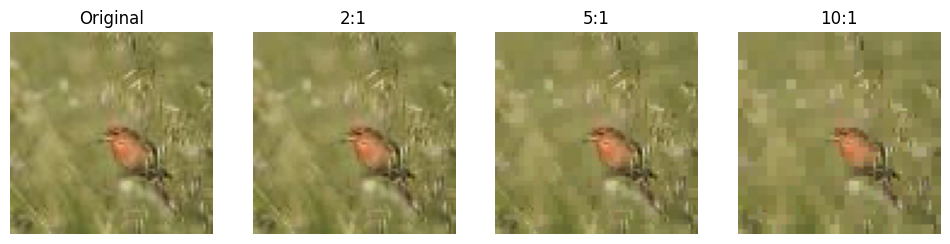

In [26]:
sample_img_path = train_dataset.samples[0][0]
original_img = Image.open(sample_img_path).convert("RGB")

compressed_2 = wavelet_compress_image(original_img, keep_ratio=0.5)
compressed_5 = wavelet_compress_image(original_img, keep_ratio=0.2)
compressed_10 = wavelet_compress_image(original_img, keep_ratio=0.1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(original_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(compressed_2)
plt.title("2:1")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(compressed_5)
plt.title("5:1")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(compressed_10)
plt.title("10:1")
plt.axis("off")

plt.show()

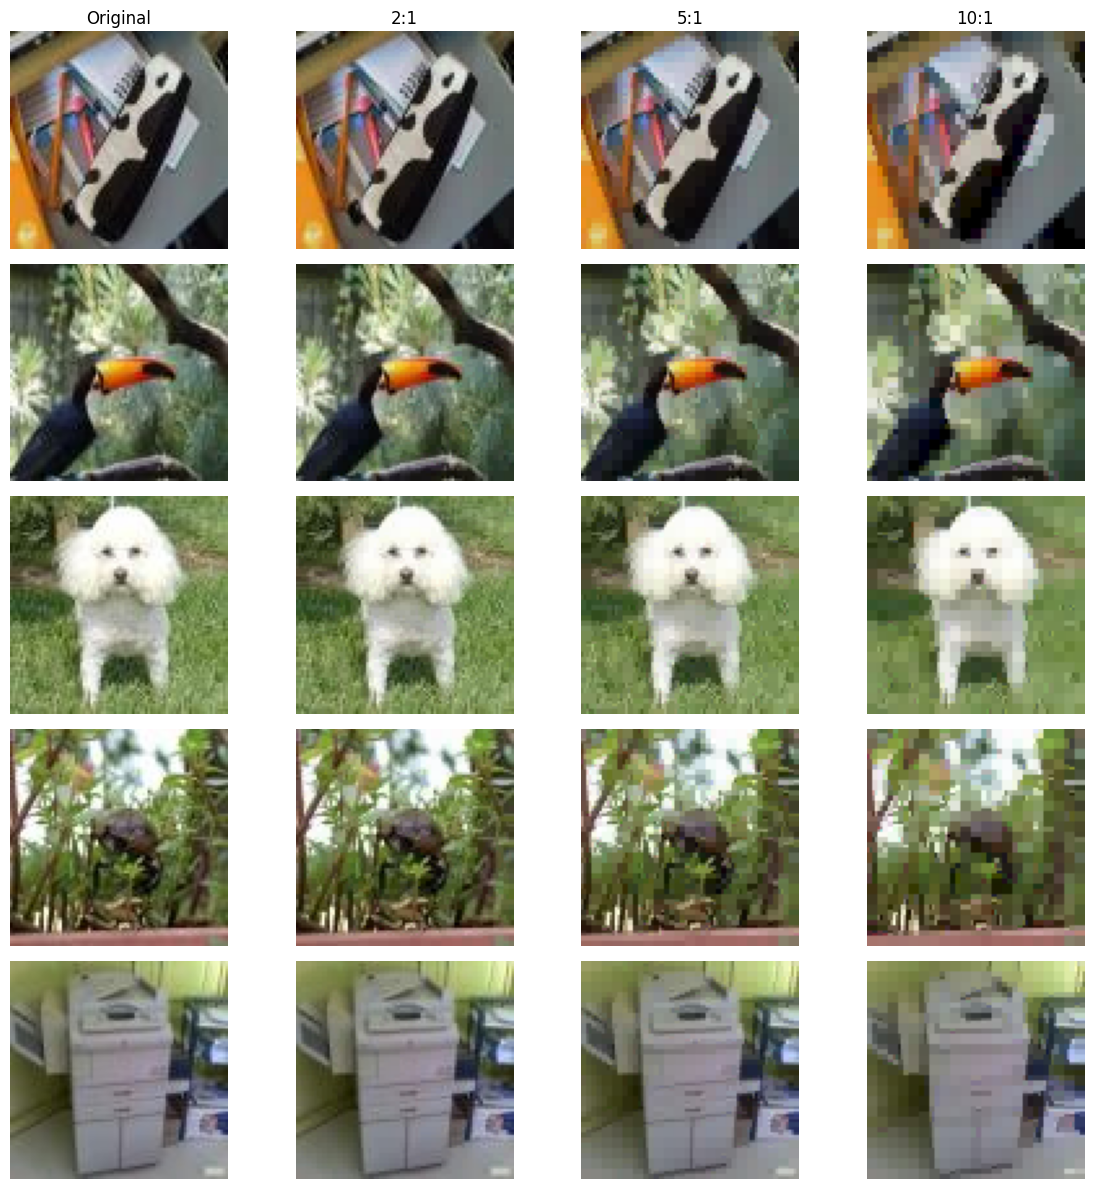

In [29]:
import random

plt.figure(figsize=(12, 12))

# pick 5 random samples from dataset
random_indices = random.sample(range(len(train_dataset)), 5)

for i, idx in enumerate(random_indices):
    img_path = train_dataset.samples[idx][0]
    img = Image.open(img_path).convert("RGB")

    c2 = wavelet_compress_image(img, keep_ratio=0.5)
    c5 = wavelet_compress_image(img, keep_ratio=0.2)
    c10 = wavelet_compress_image(img, keep_ratio=0.1)

    # Original
    plt.subplot(5, 4, i*4 + 1)
    plt.imshow(img)
    if i == 0:
        plt.title("Original")
    plt.axis("off")

    # 2:1
    plt.subplot(5, 4, i*4 + 2)
    plt.imshow(c2)
    if i == 0:
        plt.title("2:1")
    plt.axis("off")

    # 5:1
    plt.subplot(5, 4, i*4 + 3)
    plt.imshow(c5)
    if i == 0:
        plt.title("5:1")
    plt.axis("off")

    # 10:1
    plt.subplot(5, 4, i*4 + 4)
    plt.imshow(c10)
    if i == 0:
        plt.title("10:1")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [30]:
from torch.utils.data import Dataset

class CompressedImageDataset(Dataset):
    def __init__(self, original_dataset, keep_ratio):
        self.original_dataset = original_dataset
        self.keep_ratio = keep_ratio
        self.transform = original_dataset.transform

    def __len__(self):
        return len(self.original_dataset)

    def __getitem__(self, idx):
        img_path, label = self.original_dataset.samples[idx]
        img = Image.open(img_path).convert("RGB")

        compressed_img = wavelet_compress_image(img, keep_ratio=self.keep_ratio)

        if self.transform:
            compressed_img = self.transform(compressed_img)

        return compressed_img, label

In [31]:
def evaluate_model(model, data_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [32]:
compression_settings = {
    "Original": None,
    "2:1": 0.5,
    "5:1": 0.2,
    "10:1": 0.1
}

resnet_results = {}

for name, keep_ratio in compression_settings.items():
    if keep_ratio is None:
        loader = test_loader
    else:
        compressed_dataset = CompressedImageDataset(test_dataset, keep_ratio)
        loader = DataLoader(compressed_dataset, batch_size=32, shuffle=False, num_workers=2)

    acc = evaluate_model(resnet18, loader)
    resnet_results[name] = acc
    print(f"ResNet-18 accuracy on {name}: {acc:.2f}%")

ResNet-18 accuracy on Original: 78.37%
ResNet-18 accuracy on 2:1: 77.69%
ResNet-18 accuracy on 5:1: 61.91%
ResNet-18 accuracy on 10:1: 20.91%


In [33]:
mobilenet_results = {}

for name, keep_ratio in compression_settings.items():
    if keep_ratio is None:
        loader = test_loader
    else:
        compressed_dataset = CompressedImageDataset(test_dataset, keep_ratio)
        loader = DataLoader(compressed_dataset, batch_size=32, shuffle=False, num_workers=2)

    acc = evaluate_model(mobilenet, loader)
    mobilenet_results[name] = acc
    print(f"MobileNetV2 accuracy on {name}: {acc:.2f}%")

MobileNetV2 accuracy on Original: 80.39%
MobileNetV2 accuracy on 2:1: 79.60%
MobileNetV2 accuracy on 5:1: 56.76%
MobileNetV2 accuracy on 10:1: 19.80%


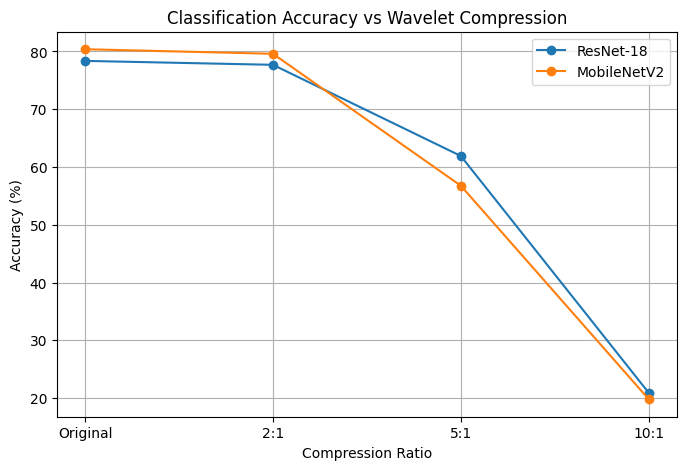

In [34]:
import matplotlib.pyplot as plt

labels = ["Original", "2:1", "5:1", "10:1"]

resnet_acc = [resnet_results[x] for x in labels]
mobilenet_acc = [mobilenet_results[x] for x in labels]

plt.figure(figsize=(8, 5))
plt.plot(labels, resnet_acc, marker="o", label="ResNet-18")
plt.plot(labels, mobilenet_acc, marker="o", label="MobileNetV2")

plt.xlabel("Compression Ratio")
plt.ylabel("Accuracy (%)")
plt.title("Classification Accuracy vs Wavelet Compression")
plt.legend()
plt.grid(True)
plt.show()